### Árvore de decisão

In [1]:
import pandas as pd
import numpy as np

### Reprodutibilidade

In [2]:
np.random.seed(42)

### Criando 150 pokémons ficticios

In [4]:
n = 150
dados = {
    'hp':np.random.randint(30,150,n),
    'ataque':np.random.randint(20,180,n),
    'defesa':np.random.randint(20,180,n),
    'velocidade':np.random.randint(20,180,n)
}

df = pd.DataFrame(dados)

### Regra para definir se é forte

In [5]:
df['forte'] = (
    (df['ataque'] + df['defesa'] + df['velocidade']) > 300
).astype(int)

df.head()

,hp,ataque,defesa,velocidade,forte
0,90,114,44,34,0
1,137,152,87,130,1
2,83,121,157,176,1
3,68,22,86,52,0
4,120,42,128,174,1


### 2. Separando treino e teste

In [6]:
from sklearn.model_selection import train_test_split

X = df[['hp', 'ataque', 'defesa', 'velocidade']]
y = df['forte']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 3. Treinando a Árvore de Decisão

In [7]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

### 4. Fazendo previsões

In [8]:
y_pred = modelo.predict(X_test)

print(y_pred[:10])

[0 0 1 1 0 1 0 1 0 1]


### 5. Avaliando o modelo

In [9]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)

print(f'Acurácia: {acuracia:.2%}')

Acurácia: 86.67%


### 6. Visualizando a árvore

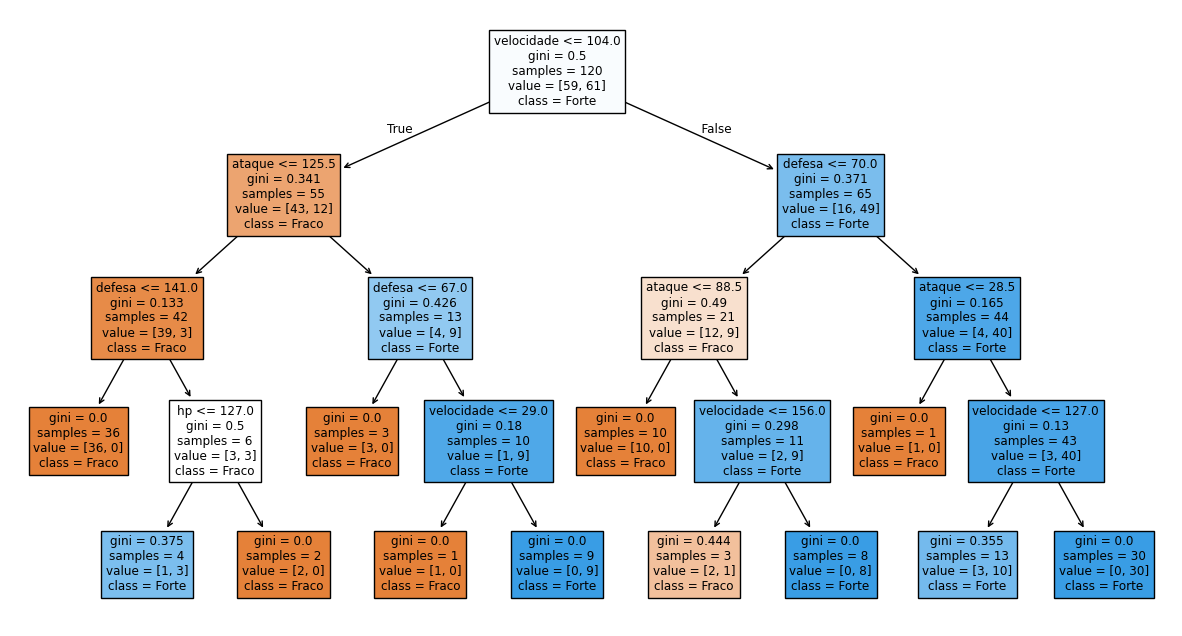

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Fraco', 'Forte'],
    filled=True
)

plt.show()